In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score

In [73]:
df = pd.read_csv("saved_files/df_boyas_tiffs_3x3.csv")
df = df.drop(columns=["Latitude", "Longitude", "Band_8", "Band_9", "Band_10", "Band_11", "Band_12", "Band_13"])
df = df.rename(columns={"Band_1" : "UltraBlue", "Band_2" : "Blue", "Band_3" : "Green", "Band_4" : "Red", "Band_5" : "NIR1", "Band_6" : "NIR2", "Band_7" : "NIR3"})
df['Date'] = pd.to_datetime(df['Date'])
dates = df["Date"].copy()
df = df.drop(columns=["Date","Buoy"])
#df.loc[:, ['UltraBlue', 'Blue', 'Green', 'Red', 'NIR1', 'NIR2', 'NIR3']] += 1

In [74]:
df.head(3)

,UltraBlue,Blue,Green,Red,NIR1,NIR2,NIR3,Chl
0,0.039216,0.047059,0.050980,0.027451,0.023529,0.015686,0.015686,0.991597
1,0.058824,0.078431,0.082353,0.062745,0.054902,0.050980,0.050980,1.195585
2,0.062745,0.074510,0.074510,0.058824,0.058824,0.054902,0.054902,1.523473


### 1. De "Análisis multisensor de la variabilidad espacio temporal de diversos parámetros biofísicos en el Mar Menor"

La fórmula que se propone en este artículo es $y = 0.6386 e^{4.7513x}$, donde $y$ es la clorofila y $x$ es la relación de $(Green - Blue)/(Green + Blue)$

In [75]:
def norm_dif(band1, band2):
    try:
        index = (band1 - band2)/(band1 + band2 + 1e-6)
    except:
        index = 0
    return index

def add_index_green_blue(data):
    df["norm_dif_green_blue"] = norm_dif(data["Green"], data["Blue"])
    df[f"index_green_blue"] = 0.6386*np.exp(4.7513*(norm_dif(data["Green"], data["Blue"])))
add_index_green_blue(df)

In [76]:
df

,UltraBlue,Blue,Green,Red,NIR1,NIR2,NIR3,Chl,norm_dif_green_blue,index_green_blue
0,0.039216,0.047059,0.050980,0.027451,0.023529,0.015686,0.015686,0.991597,0.040000,0.772265
1,0.058824,0.078431,0.082353,0.062745,0.054902,0.050980,0.050980,1.195585,0.024390,0.717062
2,0.062745,0.074510,0.074510,0.058824,0.058824,0.054902,0.054902,1.523473,0.000000,0.638600
3,0.058824,0.074510,0.078431,0.058824,0.054902,0.050980,0.050980,1.540189,0.025641,0.721336
4,0.070588,0.082353,0.090196,0.070588,0.066667,0.062745,0.062745,1.775205,0.045454,0.792542
...,...,...,...,...,...,...,...,...,...,...
555,0.054902,0.090196,0.133333,0.094118,0.098039,0.090196,0.094118,0.637809,0.192982,1.597494
556,0.039216,0.070588,0.101961,0.078431,0.086275,0.082353,0.082353,0.519570,0.181817,1.514963
557,0.027451,0.047059,0.078431,0.074510,0.082353,0.082353,0.086275,0.547043,0.249998,2.094550
558,0.039216,0.058824,0.086275,0.082353,0.086275,0.082353,0.082353,0.604849,0.189188,1.568958


In [77]:
r2 = r2_score(df["Chl"], df["index_green_blue"])
print('Train R squared: %.3f' % r2)

Train R squared: -5.009


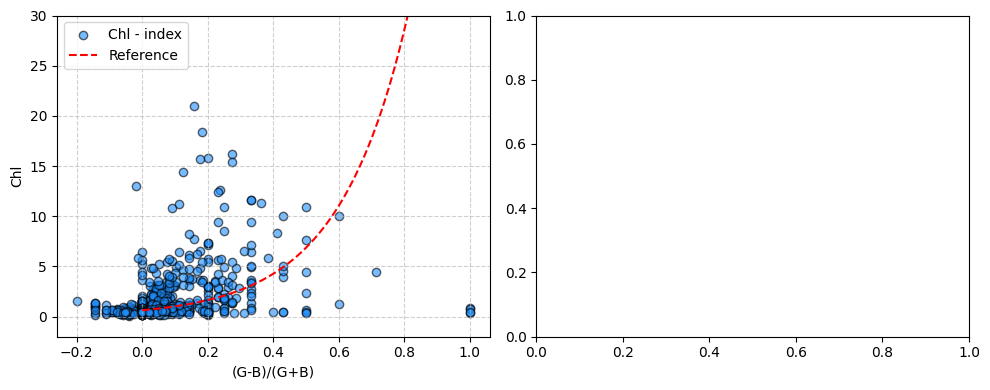

In [78]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Train plot
axes[0].scatter(df["norm_dif_green_blue"], df["Chl"], color="dodgerblue", alpha=0.6, edgecolor="k", label="Chl - index")
axes[0].plot(np.linspace(0,1, 101), 0.6386*np.exp(4.7513*(np.linspace(0,1, 101))), color="red", linestyle="--", label="Reference")
axes[0].set_xlabel("(G-B)/(G+B)")
axes[0].set_ylabel("Chl")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].set_ylim(-2,30)

# Test plot
# axes[1].scatter(y_test, test_prediction, color="orange", alpha=0.6, edgecolor="k", label="Test prediction")
# axes[1].plot(y_test, y_test, color="red", linestyle="--", label="Reference")
# axes[1].set_xlabel("Observed Chl")
# axes[1].set_ylabel("Predicted Chl")
# axes[1].legend()
# axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()